In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Downloads\subscription_churn_dataset.csv")

df.head()

,user_id,signup_date,plan_type,monthly_price,login_frequency_per_week,watch_time_hours_per_week,last_active_days,payment_failures,support_tickets,months_subscribed,cancelled
0,10001,2023-04-13,Basic,199,6,9.9,24,0,1,22,1
1,10002,2024-03-11,Basic,199,2,10.0,21,0,2,21,0
2,10003,2023-09-28,Premium,499,4,13.1,28,0,0,12,0
3,10004,2023-04-17,Basic,199,7,3.2,11,0,1,8,0
4,10005,2023-03-13,Basic,199,6,11.7,23,0,1,5,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5000 non-null   int64  
 1   signup_date                5000 non-null   object 
 2   plan_type                  5000 non-null   object 
 3   monthly_price              5000 non-null   int64  
 4   login_frequency_per_week   5000 non-null   int64  
 5   watch_time_hours_per_week  5000 non-null   float64
 6   last_active_days           5000 non-null   int64  
 7   payment_failures           5000 non-null   int64  
 8   support_tickets            5000 non-null   int64  
 9   months_subscribed          5000 non-null   int64  
 10  cancelled                  5000 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 429.8+ KB


In [4]:
df.describe()

,user_id,monthly_price,login_frequency_per_week,watch_time_hours_per_week,last_active_days,payment_failures,support_tickets,months_subscribed,cancelled
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,12500.500000,306.000000,4.017600,7.988300,14.634400,0.29720,0.597400,11.957200,0.267200
std,1443.520003,116.746417,2.010398,3.943193,8.618306,0.55112,0.769306,6.659537,0.442542
min,10001.000000,199.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000
25%,11250.750000,199.000000,3.000000,5.200000,7.000000,0.00000,0.000000,6.000000,0.000000
50%,12500.500000,299.000000,4.000000,8.000000,15.000000,0.00000,0.000000,12.000000,0.000000
75%,13750.250000,299.000000,5.000000,10.800000,22.000000,0.00000,1.000000,18.000000,1.000000
max,15000.000000,499.000000,13.000000,22.800000,29.000000,2.00000,5.000000,23.000000,1.000000


In [5]:
df.isnull().sum()

user_id                      0
signup_date                  0
plan_type                    0
monthly_price                0
login_frequency_per_week     0
watch_time_hours_per_week    0
last_active_days             0
payment_failures             0
support_tickets              0
months_subscribed            0
cancelled                    0
dtype: int64

In [7]:
df['cancelled'].value_counts()

cancelled
0    3664
1    1336
Name: count, dtype: int64

In [8]:
churn_rate = df['cancelled'].mean()

print("Churn Rate:", churn_rate)

Churn Rate: 0.2672


In [9]:
#Engagement vs Churn

df.groupby('cancelled')['login_frequency_per_week'].mean()

cancelled
0    4.136190
1    3.692365
Name: login_frequency_per_week, dtype: float64

In [10]:
#Watch Time vs Churn

df.groupby('cancelled')['watch_time_hours_per_week'].mean()

cancelled
0    8.168477
1    7.494162
Name: watch_time_hours_per_week, dtype: float64

In [11]:
#Payment Failures Impact

df.groupby('cancelled')['payment_failures'].mean()

cancelled
0    0.241812
1    0.449102
Name: payment_failures, dtype: float64

In [12]:
#Inactivity Analysis

df.groupby('cancelled')['last_active_days'].mean()

cancelled
0    13.642194
1    17.355539
Name: last_active_days, dtype: float64

In [13]:
df.corr(numeric_only=True)

,user_id,monthly_price,login_frequency_per_week,watch_time_hours_per_week,last_active_days,payment_failures,support_tickets,months_subscribed,cancelled
user_id,1.000000,-0.005776,-0.001924,0.013155,-0.006404,0.013850,-0.001684,-0.027987,0.007103
monthly_price,-0.005776,1.000000,-0.017401,0.019002,0.003697,0.002170,-0.010043,-0.008105,-0.023820
login_frequency_per_week,-0.001924,-0.017401,1.000000,-0.004804,0.027861,0.010625,0.002513,0.002492,-0.097698
watch_time_hours_per_week,0.013155,0.019002,-0.004804,1.000000,-0.019252,-0.007853,-0.018421,0.029429,-0.075678
last_active_days,-0.006404,0.003697,0.027861,-0.019252,1.000000,-0.007653,0.005312,0.004210,0.190677
payment_failures,0.013850,0.002170,0.010625,-0.007853,-0.007653,1.000000,-0.014502,-0.011413,0.166451
support_tickets,-0.001684,-0.010043,0.002513,-0.018421,0.005312,-0.014502,1.000000,-0.004965,0.012852
months_subscribed,-0.027987,-0.008105,0.002492,0.029429,0.004210,-0.011413,-0.004965,1.000000,0.004967
cancelled,0.007103,-0.023820,-0.097698,-0.075678,0.190677,0.166451,0.012852,0.004967,1.000000


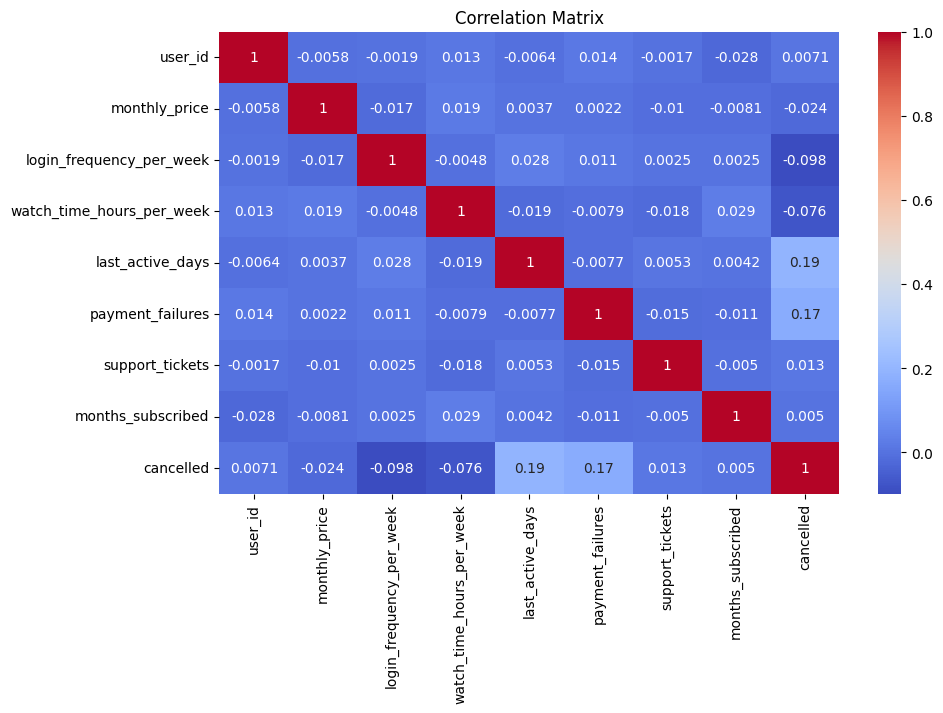

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()